# Plan Position Indicator
A Plan Position Indicator (PPI) plot is a common plot requested by radar scientists. Let's show how to create this plot using `xradar`

## Imports

In [1]:
import cmweather  # noqa
from open_radar_data import DATASETS

import xradar as xd

In [2]:
import cartopy
import matplotlib.pyplot as plt

## Read in some data

Fetching CfRadial1 radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [3]:
filename = DATASETS.fetch("cfrad.20080604_002217_000_SPOL_v36_SUR.nc")

Read the data using the `cfradial1` engine

In [4]:
radar = xd.io.open_cfradial1_datatree(filename, first_dim="auto")
display(radar)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S1 1B ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes: (12/13)
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       comment:             
│       instrument_name:     SPOLRVP8
│       site_name:           
│       scan_name:           
│       scan_id:             0
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:16:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range)

## Add georeferencing
We can use the georeference function, or the accessor to add our georeference information!

### Georeference Accessor
If you prefer the accessor (`.xradar.georefence()`), this is how you would add georeference information to your radar object.

In [5]:
radar = radar.xradar.georeference()
display(radar)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S1 1B ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes: (12/13)
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       comment:             
│       instrument_name:     SPOLRVP8
│       site_name:           
│       scan_name:           
│       scan_id:             0
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB 0.5164 0.5219 ... 0.5219
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B 22.53
│           longitude                  float64 8B 120.4
│           altitude                   float64 8B 45.0
│           crs_wkt                    int64 8B 0
│           x                          (azimuth, range) float64 4MB 0.0 ... -1.955e+03
│           y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
│           z                          (azimuth, range) float64 4MB 46.35 ... 2.718e+03
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB 1.104 1.104 ... 1.104 1.104
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:16:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B 22.53
│           longitude                  float64 8B 120.4
│           altitude                   float64 8B 45.0
│           crs_wkt                    int64 8B 0
│           x                          (azimuth, range) float64 4MB 0.0 ... -1.954e+03
│           y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
│           z                          (azimuth, range) float64 4MB 47.89 ... 4.236e+03
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U2

Please observe, that the additional coordinates `x`, `y`, `z` have been added to the dataset. This will also add `spatial_ref` CRS information on the used Azimuthal Equidistant Projection.

In [6]:
radar["sweep_0"]

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:                    (sweep: 9, azimuth: 483, range: 996)
    Coordinates:
      * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
        elevation                  (azimuth) float32 2kB 0.5164 0.5219 ... 0.5219
        time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
      * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
        latitude                   float64 8B 22.53
        longitude                  float64 8B 120.4
        altitude                   float64 8B 45.0
        crs_wkt                    int64 8B 0
        x                          (azimuth, range) float64 4MB 0.0 ... -1.955e+03
        y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
        z                          (azimuth, range) float64 4MB 46.35 ... 2.718e+03
    Dimensions without coordinates: sweep
    Data variables: (12/18)
        sweep_number               int32 4B ...
        sweep_mode                 <U20 80B 'azimuth_surveillance'
        prt_mode                   |S32 32B ...
        follow_mode                |S32 32B ...
        sweep_fixed_angle          float32 4B ...
        pulse_width                (azimuth) float32 2kB ...
        ...                         ...
        r_calib_index              (azimuth) int8 483B ...
        measured_transmit_power_h  (azimuth) float32 2kB ...
        measured_transmit_power_v  (azimuth) float32 2kB ...
        scan_rate                  (azimuth) float32 2kB ...
        DBZ                        (azimuth, range) float32 2MB ...
        VR                         (azimuth, range) float32 2MB ...

### Use the Function
We can also use the function `xd.geoference.get_x_y_z_tree` function if you prefer that method.

In [7]:
radar = xd.georeference.get_x_y_z_tree(radar)
display(radar["sweep_0"])

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:                    (sweep: 9, azimuth: 483, range: 996)
    Coordinates:
      * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
        elevation                  (azimuth) float32 2kB 0.5164 0.5219 ... 0.5219
        time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
      * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
        latitude                   float64 8B 22.53
        longitude                  float64 8B 120.4
        altitude                   float64 8B 45.0
        crs_wkt                    int64 8B 0
        x                          (azimuth, range) float64 4MB 0.0 ... -1.955e+03
        y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
        z                          (azimuth, range) float64 4MB 46.35 ... 2.718e+03
    Dimensions without coordinates: sweep
    Data variables: (12/18)
        sweep_number               int32 4B ...
        sweep_mode                 <U20 80B 'azimuth_surveillance'
        prt_mode                   |S32 32B ...
        follow_mode                |S32 32B ...
        sweep_fixed_angle          float32 4B ...
        pulse_width                (azimuth) float32 2kB ...
        ...                         ...
        r_calib_index              (azimuth) int8 483B ...
        measured_transmit_power_h  (azimuth) float32 2kB ...
        measured_transmit_power_v  (azimuth) float32 2kB ...
        scan_rate                  (azimuth) float32 2kB ...
        DBZ                        (azimuth, range) float32 2MB ...
        VR                         (azimuth, range) float32 2MB ...

## Plot our Data

### Plot simple PPI

Now, let's create our PPI plot! We just use the newly created 2D-coordinates `x` and `y` to create a meshplot.

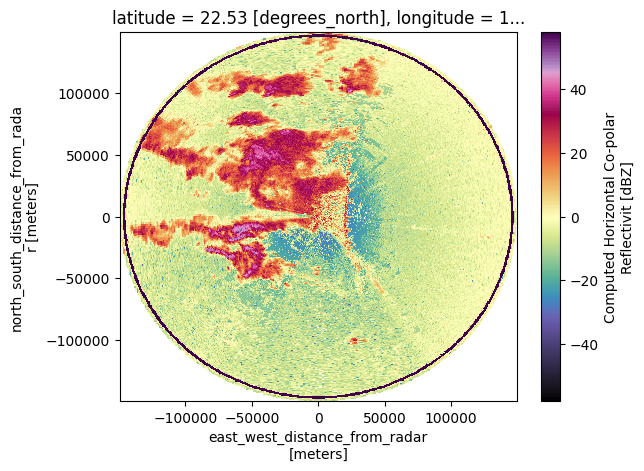

In [8]:
radar["sweep_0"]["DBZ"].plot(x="x", y="y", cmap="ChaseSpectral")

### Plot PPI on map with cartopy

If you have `cartopy` installed, you can easily plot on maps. We first have to extract the CRS from the dataset and to wrap it in a `cartopy.crs.Projection`.

In [9]:
proj_crs = xd.georeference.get_crs(radar["sweep_0"].ds)
cart_crs = cartopy.crs.Projection(proj_crs)

Second, we create a matplotlib GeoAxes and a nice map.

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\cartopy\mpl\geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)


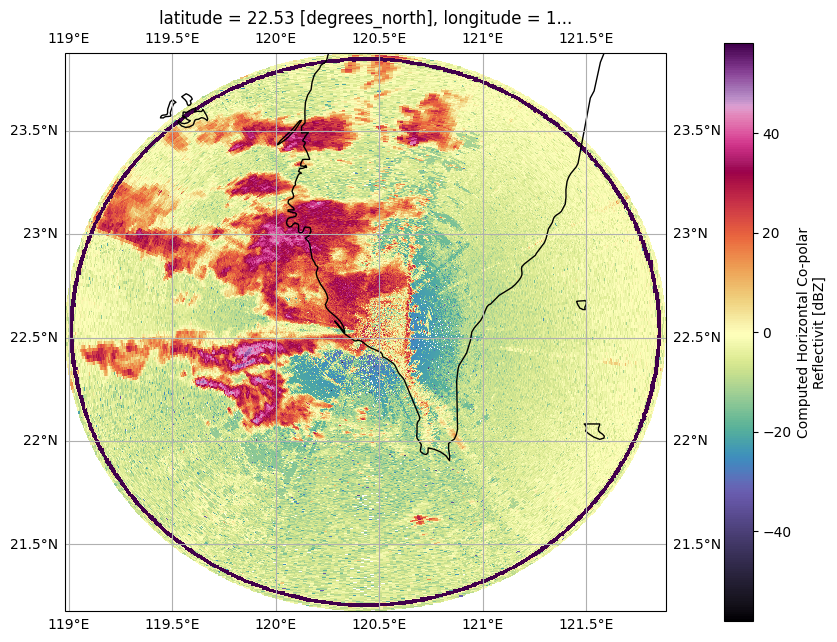

In [10]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=cartopy.crs.PlateCarree())
radar["sweep_0"]["DBZ"].plot(
    x="x",
    y="y",
    cmap="ChaseSpectral",
    transform=cart_crs,
    cbar_kwargs=dict(pad=0.075, shrink=0.75),
)
ax.coastlines()
ax.gridlines(draw_labels=True)